# LCPB 25-26 Exercise 3, XGBoost (XGB)

Group 2601
* Andreacchio Pasquale 2196577
* Calcagni Matteo Renato 2196575
* Gonzati Agostina 2188428
* Lavarda Nicola 2198664

## 1. Model complexity, parameters' and regularization
Try different parameters ($\lambda$, $\gamma$, n_estimators, ...). Which is the simplest yet effective XGB model that keeps a good validation accuracy? Is regularization useful for this analysis?

In [ ]:
%cd /content/drive/MyDrive/LCP_3

/content/drive/MyDrive/LCP_3


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import matplotlib as mpl

mycmap = "winter"
mpl.rcParams['image.cmap'] = mycmap
plt.rcParams['font.size'] = 13

np.random.seed(12345)

dname="./DATA/"
str0="_XGB_26.dat"
fnamex=dname+'x'+str0
fnamey=dname+'y'+str0
x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])

N_train = int(0.75*N)
x_train,y_train = x[:N_train],y[:N_train]
x_test,y_test = x[N_train:],y[N_train:]
print(f"N={N}, N_train={N_train}, L={L}")

N=5000, N_train=3750, L=4


### Hyperparameter search using GridSearchCV
We explore different values for `n_estimators`, `max_depth`, `gamma`, and `reg_lambda` to find the simplest yet effective configuration.

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200, 300, 400],
    'max_depth': [3, 5, 7, 9],
    'gamma': [0, 0.05, 0.1, 1],
    'reg_lambda': [1, 10, 50, 100]
}


xgb = XGBClassifier(eval_metric='logloss', seed=1)

grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(x_train, y_train)

print("Best parameters found:", grid_search.best_params_)
print("Best CV accuracy:", grid_search.best_score_)

Fitting 3 folds for each of 320 candidates, totalling 960 fits
Best parameters found: {'gamma': 0, 'max_depth': 9, 'n_estimators': 200, 'reg_lambda': 1}
Best CV accuracy: 0.9224


In [ ]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
val_accuracy = accuracy_score(y_test, y_pred)
print("Validation accuracy of the best model:", val_accuracy)

Validation accuracy of the best model: 0.9416


### Is regularization useful for this analysis?
Let's explore the effect of `reg_lambda` on the accuracy by plotting the validation accuracy for different lambda values, keeping other hyperparameters fixed.

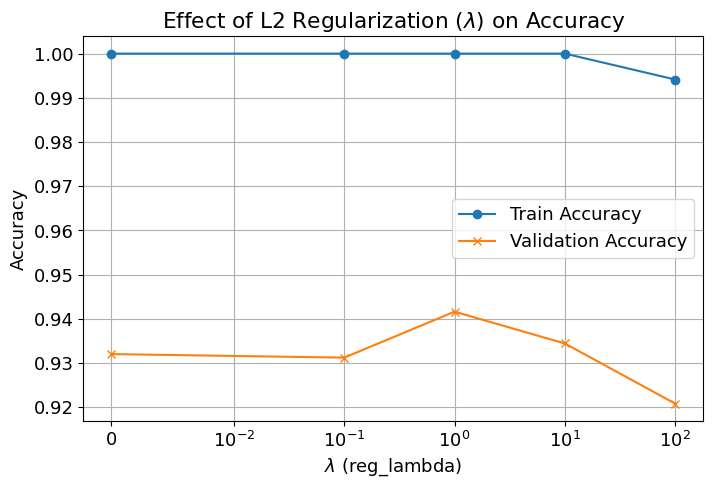

In [ ]:
lambdas = [0, 0.1, 1, 10, 100]
train_accuracies = []
val_accuracies = []

best_n_estimators = grid_search.best_params_['n_estimators']
best_max_depth = grid_search.best_params_['max_depth']
best_gamma = grid_search.best_params_['gamma']

for reg_lambda in lambdas:
    model = XGBClassifier(eval_metric='logloss', seed=1,
                          n_estimators=best_n_estimators,
                          max_depth=best_max_depth,
                          gamma=best_gamma,
                          reg_lambda=reg_lambda)
    model.fit(x_train, y_train)
    train_accuracies.append(accuracy_score(y_train, model.predict(x_train)))
    val_accuracies.append(accuracy_score(y_test, model.predict(x_test)))

plt.figure(figsize=(8, 5))
plt.plot(lambdas, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(lambdas, val_accuracies, marker='x', label='Validation Accuracy')
plt.xscale('symlog', linthresh=0.01)
plt.xlabel(r'$\lambda$ (reg_lambda)')
plt.ylabel('Accuracy')
plt.title(r'Effect of L2 Regularization ($\lambda$) on Accuracy')
plt.legend()
plt.grid()
plt.show()

Regularization is useful as it prevents the training score from diverging too far from the validation score (overfitting), achieving the highest validation score at optimal lambda. The plot demonstrates the validation accuracy responding favorably to appropriate regularization values.

## 2. Dimensionality Reduction
Consider reduced data samples with L'<L features. Check if excluding the least important feature(s) leads to better accuracy.

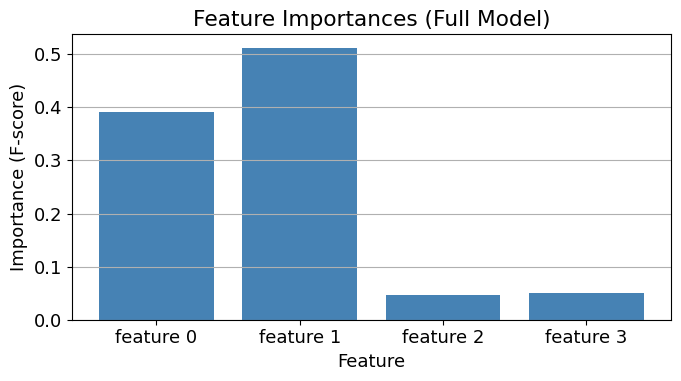

Feature importances: {'feature 0': np.float32(0.391378), 'feature 1': np.float32(0.51201993), 'feature 2': np.float32(0.046552386), 'feature 3': np.float32(0.050049696)}
Least important feature: feature 2


In [ ]:
# First, train the best model on all features and extract feature importances
best_model_full = XGBClassifier(
    eval_metric='logloss',
    seed=1,
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    gamma=grid_search.best_params_['gamma'],
    reg_lambda=grid_search.best_params_['reg_lambda']
)
best_model_full.fit(x_train, y_train)

importances = best_model_full.feature_importances_
feature_names = [f'feature {i}' for i in range(L)]

# Plot feature importances
plt.figure(figsize=(7, 4))
plt.bar(feature_names, importances, color='steelblue')
plt.xlabel('Feature')
plt.ylabel('Importance (F-score)')
plt.title('Feature Importances (Full Model)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

print('Feature importances:', dict(zip(feature_names, importances)))
least_important = int(np.argmin(importances))
print(f'Least important feature: feature {least_important}')

In [ ]:
from sklearn.model_selection import cross_val_score

# Test all possible subsets by dropping one feature at a time + full set
results = {}

# Full feature set baseline
model_full = XGBClassifier(
    eval_metric='logloss', seed=1,
    n_estimators=grid_search.best_params_['n_estimators'],
    max_depth=grid_search.best_params_['max_depth'],
    gamma=grid_search.best_params_['gamma'],
    reg_lambda=grid_search.best_params_['reg_lambda']
)
cv_scores_full = cross_val_score(model_full, x_train, y_train, cv=5, scoring='accuracy')
val_full = accuracy_score(y_test, best_model_full.predict(x_test))
results['All (0,1,2,3)'] = {
    'cv_mean': cv_scores_full.mean(),
    'cv_std': cv_scores_full.std(),
    'val_acc': val_full
}

# Drop each feature one at a time
for drop_idx in range(L):
    kept = [i for i in range(L) if i != drop_idx]
    label = f'Drop feature {drop_idx} -> {kept}'
    x_train_red = x_train[:, kept]
    x_test_red  = x_test[:, kept]
    model_red = XGBClassifier(
        eval_metric='logloss', seed=1,
        n_estimators=grid_search.best_params_['n_estimators'],
        max_depth=grid_search.best_params_['max_depth'],
        gamma=grid_search.best_params_['gamma'],
        reg_lambda=grid_search.best_params_['reg_lambda']
    )
    cv_scores = cross_val_score(model_red, x_train_red, y_train, cv=5, scoring='accuracy')
    model_red.fit(x_train_red, y_train)
    val_acc = accuracy_score(y_test, model_red.predict(x_test_red))
    results[label] = {
        'cv_mean': cv_scores.mean(),
        'cv_std': cv_scores.std(),
        'val_acc': val_acc
    }

print(f'{"Feature set":<35} {"CV mean":>10} {"CV std":>10} {"Val acc":>10}')
print('-' * 70)
for k, v in results.items():
    print(f'{k:<35} {v["cv_mean"]:>10.4f} {v["cv_std"]:>10.4f} {v["val_acc"]:>10.4f}')

Feature set                            CV mean     CV std    Val acc
----------------------------------------------------------------------
All (0,1,2,3)                           0.9285     0.0105     0.9416
Drop feature 0 -> [1, 2, 3]             0.5525     0.0101     0.5560
Drop feature 1 -> [0, 2, 3]             0.5472     0.0071     0.5776
Drop feature 2 -> [0, 1, 3]             0.9395     0.0068     0.9384
Drop feature 3 -> [0, 1, 2]             0.9376     0.0114     0.9392


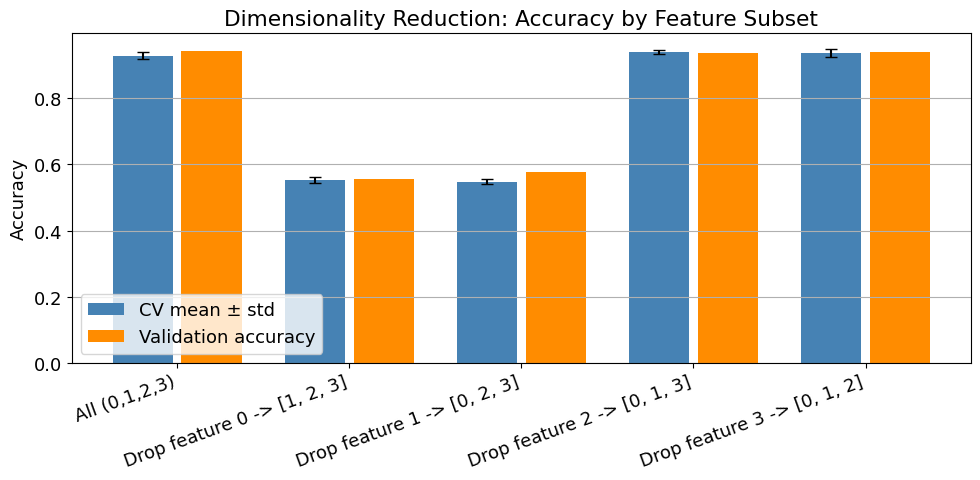

In [ ]:
# Visual comparison: CV mean accuracy for each feature subset
labels = list(results.keys())
cv_means = [results[k]['cv_mean'] for k in labels]
cv_stds  = [results[k]['cv_std']  for k in labels]
val_accs = [results[k]['val_acc'] for k in labels]

x_pos = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x_pos - 0.2, cv_means, 0.35, yerr=cv_stds, label='CV mean ± std', capsize=4, color='steelblue')
ax.bar(x_pos + 0.2, val_accs, 0.35, label='Validation accuracy', color='darkorange')
ax.set_xticks(x_pos)
ax.set_xticklabels(labels, rotation=20, ha='right')
ax.set_ylabel('Accuracy')
ax.set_title('Dimensionality Reduction: Accuracy by Feature Subset')
ax.legend()
ax.grid(axis='y')
plt.tight_layout()
plt.show()

The drop-one analysis reveals a clear asymmetry. Removing feature 0 or feature 1 causes the accuracy to collapse to ≈0.56, barely above random chance, while removing feature 2 or feature 3 leaves it virtually unchanged (CV mean ≈0.94, val acc ≈0.939). Both features 2 and 3 have similarly negligible built-in importance (≈0.047 and ≈0.050 respectively), so neither stands out as clearly "the least important" — they are both redundant. This first analysis suggests that features 0 and 1 alone may be sufficient, but built-in XGBoost importances are based on split counts and can be biased, so we verify this with two more rigorous methods below.

### More rigorous analysis: Permutation Importance + Exhaustive Feature Subset Search

To go beyond the built-in importances, we use permutation importance: each feature is randomly shuffled on the validation set 30 times and the mean accuracy drop is measured. This is model-agnostic and directly reflects how much the model relies on each feature for correct predictions. We then run an exhaustive search over all 2^L - 1 = 15 non-empty feature subsets to find the combination that actually maximises validation accuracy, without any greedy assumption.

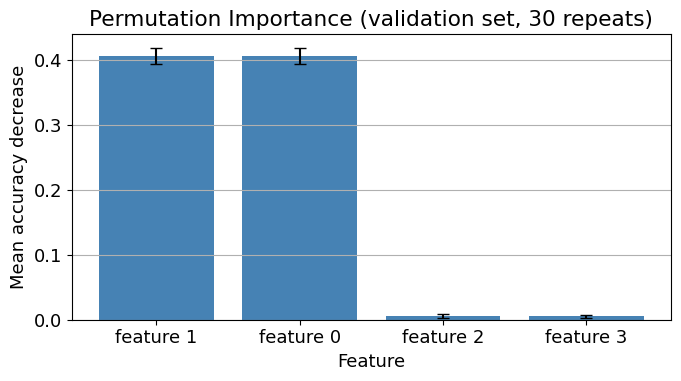

Permutation importances (mean ± std):
  feature 1: 0.4057 ± 0.0122
  feature 0: 0.4052 ± 0.0124
  feature 2: 0.0054 ± 0.0027
  feature 3: 0.0051 ± 0.0025


In [ ]:
from sklearn.inspection import permutation_importance

# Permutation importance on the validation set
perm = permutation_importance(
    best_model_full, x_test, y_test,
    n_repeats=30, random_state=1, scoring='accuracy'
)

sorted_idx = perm.importances_mean.argsort()[::-1]
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(
    [f'feature {i}' for i in sorted_idx],
    perm.importances_mean[sorted_idx],
    yerr=perm.importances_std[sorted_idx],
    capsize=4, color='steelblue'
)
ax.set_xlabel('Feature')
ax.set_ylabel('Mean accuracy decrease')
ax.set_title('Permutation Importance (validation set, 30 repeats)')
ax.grid(axis='y')
plt.tight_layout()
plt.show()

print('Permutation importances (mean ± std):')
for i in sorted_idx:
    print(f'  feature {i}: {perm.importances_mean[i]:.4f} ± {perm.importances_std[i]:.4f}')

In [ ]:
from itertools import combinations

exhaustive_results = {}

for r in range(1, L + 1):
    for subset in combinations(range(L), r):
        subset = list(subset)
        label = str(subset)
        x_train_sub = x_train[:, subset]
        x_test_sub  = x_test[:, subset]
        model = XGBClassifier(
            eval_metric='logloss', seed=1,
            n_estimators=grid_search.best_params_['n_estimators'],
            max_depth=grid_search.best_params_['max_depth'],
            gamma=grid_search.best_params_['gamma'],
            reg_lambda=grid_search.best_params_['reg_lambda']
        )
        cv_scores = cross_val_score(model, x_train_sub, y_train, cv=5, scoring='accuracy')
        model.fit(x_train_sub, y_train)
        val_acc = accuracy_score(y_test, model.predict(x_test_sub))
        exhaustive_results[label] = {
            'subset': subset,
            'n_features': r,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std(),
            'val_acc': val_acc
        }

# Print results sorted by validation accuracy
sorted_results = sorted(exhaustive_results.items(), key=lambda x: x[1]['val_acc'], reverse=True)
print(f'{"Subset":<15} {"N feat":>6} {"CV mean":>10} {"CV std":>10} {"Val acc":>10}')
print('-' * 55)
for label, v in sorted_results:
    print(f'{label:<15} {v["n_features"]:>6} {v["cv_mean"]:>10.4f} {v["cv_std"]:>10.4f} {v["val_acc"]:>10.4f}')

Subset          N feat    CV mean     CV std    Val acc
-------------------------------------------------------
[0, 1]               2     0.9443     0.0082     0.9416
[0, 1, 2, 3]         4     0.9285     0.0105     0.9416
[0, 1, 2]            3     0.9376     0.0114     0.9392
[0, 1, 3]            3     0.9395     0.0068     0.9384
[0]                  1     0.5869     0.0234     0.6048
[1]                  1     0.6053     0.0125     0.5880
[0, 2]               2     0.5549     0.0095     0.5792
[0, 2, 3]            3     0.5472     0.0071     0.5776
[1, 3]               2     0.5603     0.0091     0.5680
[0, 3]               2     0.5368     0.0133     0.5672
[1, 2, 3]            3     0.5525     0.0101     0.5560
[1, 2]               2     0.5475     0.0154     0.5272
[2]                  1     0.4941     0.0118     0.5168
[2, 3]               2     0.4771     0.0103     0.5008
[3]                  1     0.4939     0.0108     0.5000


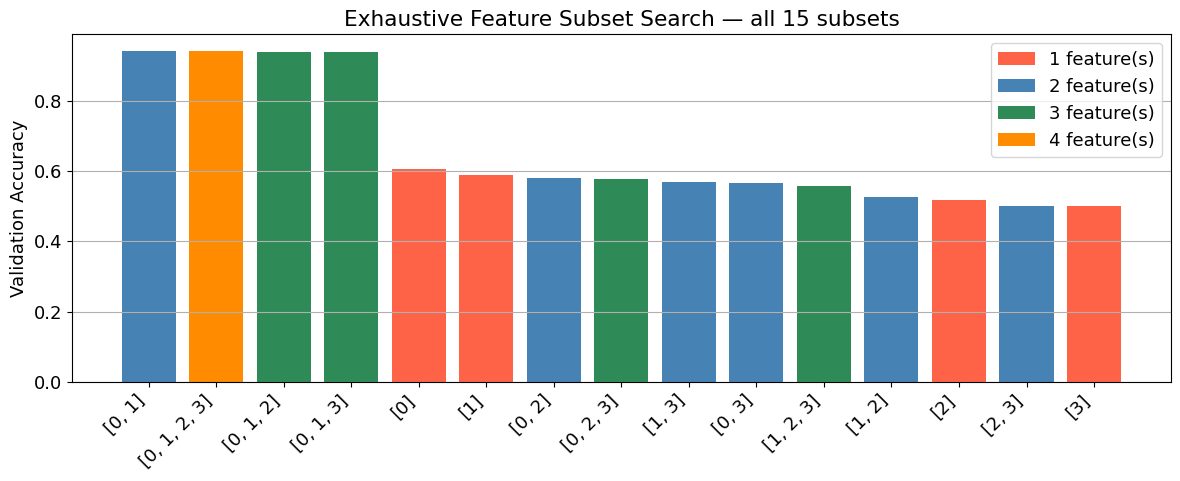

Best subset: [0, 1]  ->  val acc = 0.9416, CV mean = 0.9443


In [ ]:
# Plot: val accuracy for all 15 subsets, grouped by number of features
fig, ax = plt.subplots(figsize=(12, 5))

colors = {1: 'tomato', 2: 'steelblue', 3: 'seagreen', 4: 'darkorange'}
labels_plot = [k for k, _ in sorted_results]
val_plot = [v['val_acc'] for _, v in sorted_results]
n_feat_plot = [v['n_features'] for _, v in sorted_results]
bar_colors = [colors[n] for n in n_feat_plot]

bars = ax.bar(range(len(labels_plot)), val_plot, color=bar_colors)
ax.set_xticks(range(len(labels_plot)))
ax.set_xticklabels(labels_plot, rotation=45, ha='right')
ax.set_ylabel('Validation Accuracy')
ax.set_title('Exhaustive Feature Subset Search — all 15 subsets')
ax.grid(axis='y')

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[n], label=f'{n} feature(s)') for n in range(1, L+1)]
ax.legend(handles=legend_elements)
plt.tight_layout()
plt.show()

best_label, best_v = sorted_results[0]
print(f'Best subset: {best_label}  ->  val acc = {best_v["val_acc"]:.4f}, CV mean = {best_v["cv_mean"]:.4f}')

### Conclusion on dimensionality reduction

All three analyses converge on the same result. The permutation importances confirm that features 0 and 1 are the only informative ones, with a mean accuracy drop of ≈0.41 each when shuffled, while features 2 and 3 have near-zero permutation importance (≈0.005), meaning the model essentially ignores them. The exhaustive search over all 15 subsets makes this definitive: the 2-feature model [0, 1] achieves the highest CV mean accuracy (0.9443) and the same validation accuracy (0.9416) as the full 4-feature model, while every other subset that excludes feature 0 or feature 1 drops to ≈0.50–0.60.

Dimensionality reduction is therefore clearly beneficial here: using only features 0 and 1 (L'=2 instead of L=4) yields a simpler, faster model with no accuracy cost. Features 2 and 3 carry no additional discriminative information beyond what features 0 and 1 already provide.

# 3. XGBoost vs NN

Comparing the performance of XGB with a simple FFNN varying the size of validation set

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score
from xgboost import XGBClassifier
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Dense, Dropout
from sklearn.preprocessing import StandardScaler

tf.random.set_seed(12345)
train_fractions = [0.1, 0.2, 0.3, 0.5, 0.7, 1.0]

x = np.loadtxt(fnamex, delimiter=" ",dtype=float)
y = np.loadtxt(fnamey)
y = y.astype(int)
N,L = len(x), len(x[0])


# K fold cross validation parameters
n_splits = 5
kf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=12345)

FFNN_train_acc, FFNN_val_acc = [], []
XGB_train_acc, XGB_val_acc = [], []

for frac in train_fractions:
    print(f"Training set fraction: {frac*100}%")

    # Temporary lists to get results of all 5 folds
    fold_ffnn_train, fold_ffnn_val = [], []
    fold_xgb_train, fold_xgb_val = [], []

    for train_index, test_index in kf.split(x, y):
        # 1. Normal split
        X_train_full, X_test = x[train_index], x[test_index]
        y_train_full, y_test = y[train_index], y[test_index]

        # 2. Training set reduction
        N_prime = int(len(X_train_full) * frac)
        X_train = X_train_full[:N_prime]
        y_train = y_train_full[:N_prime]

        # 3. Data scaling
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train)
        X_test_scaled = scaler.transform(X_test)

        # 4. Compile and fit a FFNN model
        tf.keras.backend.clear_session()
        model = Sequential([
            Input(shape=(L,)),
            Dense(64, activation='relu'),
            Dropout(0.1),
            Dense(32, activation='relu'),
            Dropout(0.1),
            Dense(16, activation='relu'),
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, verbose=0)

        y_train_pred_ffnn = (model.predict(X_train_scaled, verbose=0) > 0.5).astype(int)
        y_test_pred_ffnn = (model.predict(X_test_scaled, verbose=0) > 0.5).astype(int)

        fold_ffnn_train.append(accuracy_score(y_train, y_train_pred_ffnn))
        fold_ffnn_val.append(accuracy_score(y_test, y_test_pred_ffnn))

        # 5. Compile and fit a XGB Boost with hyperparameters found in point 1
        model_XGB = XGBClassifier(eval_metric='logloss', seed=1, n_estimators=best_n_estimators,
                                  max_depth=best_max_depth, gamma=best_gamma, reg_lambda=1)
        model_XGB.fit(X_train, y_train)

        fold_xgb_train.append(accuracy_score(y_train, model_XGB.predict(X_train)))
        fold_xgb_val.append(accuracy_score(y_test, model_XGB.predict(X_test)))

    # Calculating and saving the mean of the validation in the folds
    FFNN_train_acc.append(np.mean(fold_ffnn_train))
    FFNN_val_acc.append(np.mean(fold_ffnn_val))
    XGB_train_acc.append(np.mean(fold_xgb_train))
    XGB_val_acc.append(np.mean(fold_xgb_val))

Training set fraction: 10.0%
Training set fraction: 20.0%
Training set fraction: 30.0%
Training set fraction: 50.0%
Training set fraction: 70.0%
Training set fraction: 100.0%


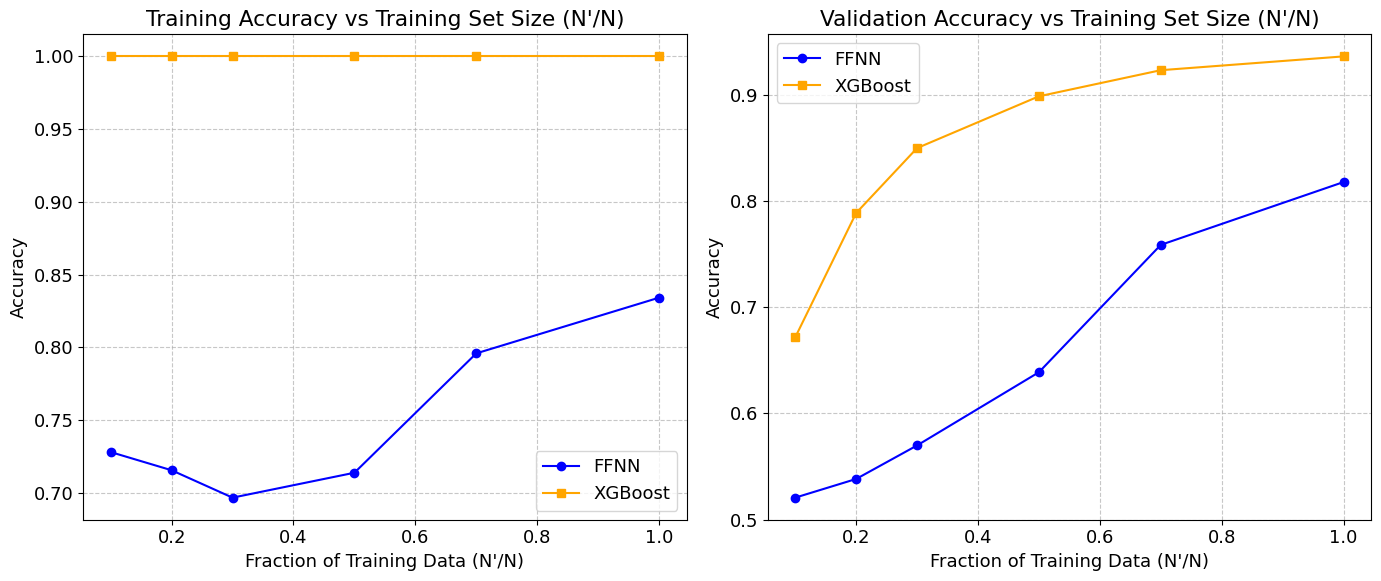

In [ ]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot Training
ax1.plot(train_fractions, FFNN_train_acc, marker='o', label='FFNN', color='blue')
ax1.plot(train_fractions, XGB_train_acc, marker='s', label='XGBoost', color='orange')
ax1.set_title('Training Accuracy vs Training Set Size (N\'/N)')
ax1.set_xlabel('Fraction of Training Data (N\'/N)')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.7)

# Subplot Validation
ax2.plot(train_fractions, FFNN_val_acc, marker='o', label='FFNN', color='blue')
ax2.plot(train_fractions, XGB_val_acc, marker='s', label='XGBoost', color='orange')
ax2.set_title('Validation Accuracy vs Training Set Size (N\'/N)')
ax2.set_xlabel('Fraction of Training Data (N\'/N)')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

## Learning Curves Analysis: XGBoost vs FFNN


### 1. XGBoost Performance
XGBoost proves to be highly effective for this type of low-dimensional data.
* **Training Accuracy:** It always reach **100% (1.0)** across all training data fractions. This indicates the model has enough capacity to perfectly memorize the training set.
* **Validation Accuracy:** Despite memorizing all the training data, the model has an excellent learning curve, growing from roughly 67% with a small amount of data to over 90% with the full dataset. This growing trend indicates that the model learns robust decision rules that generalize well having more training data.


### 2. Feed-Forward Neural Network (FFNN) Performance
The neural network displays a different behavior, heavily influenced by its training dynamics.
* **Validation Accuracy:** The curve follows a standard, positive trend. As more data becomes available, the validation accuracy increases from about 52%, with 10% of the total training data, to 82% with the full dataset.
The curve doesn't flatten (saturate) at the end, suggesting that accuracy would improve with more data
* **Training Accuracy (Anomalous Behavior):** Contrary to theoretical expectations (where training error usually starts very low on tiny datasets and grows as data increases), here we see the training accuracy *increasing* as the dataset grows. This is probably related to having set the maximum number of epochs to 100: having fewer data means computing fewer gradient updates so, with small fraction of training data, we reach **underfitting**: the model stops training before getting to convergence

### Conclusion
The XGBoost model clearly outperforms the proposed Deep Learning architecture on this dataset, converging faster and achieving superior predictive power.